## LRTC-TSCAD Demo

This demo implements **LRTC-TSCAD**, an extension of LRTC-TMCP that replaces the truncated-norm penalty from `MCP` with `SCAD`. 

SCAD function is defined as follows:
$$
\psi_{\lambda, \gamma} \left( x \right) = \left\{
\begin{aligned}
& \lambda |x|, & |x| < \lambda, \\
& \frac{- x ^ 2 + 2 \gamma \lambda |x| - \lambda ^ 2}{2 (\gamma - 1)}, & \lambda \leq |x| < \gamma \lambda, \\
& \frac{\gamma + 1}{2} \lambda ^ 2 , & |x| \geq \gamma \lambda.\\
\end{aligned}\right.
$$

And the related truncated norm is defined as:
$$
\| \mathcal{X} \|_{\theta, \lambda, \gamma} = \sum_{k=1}^d \alpha_k \left( \sum_{i=r_k + 1}^{m_k}  \psi_{\lambda, \gamma} \left( \sigma_i \left( \mathbf{X}_{(k)} \right) \right) \right).
$$
where $m_k = \min \{ n_k, \prod_{j \neq k} n_j \}$, $r_k = \lceil \theta m_k \rceil, k = 1, 2, \dots, d$, and $\theta \in [ 0, \, 1]$ is the truncated rate.

The method is evaluated on the same traffic data as in the original paper (`Hangzhou`, `Seattle`, `Portland`, `PeMS`), under three missing patterns: random, non-random, and blackout. The optimal hyperparameters and their corresponding results are recorded in the `hyper_parameters` dictionary below.

Reported MAPE and RMSE are averaged across missing rates of `10%, 30%, 50%, 70%, and 90%` for each missing pattern, consistent with the evaluation protocol in the paper. And this demo uses a subset of `30%, 50%, and 70%` for brevity.

In [ ]:
import os
import time
import torch
import logging
import numpy as np
import matplotlib.pyplot as plt

from utils import logger_info, logger_close
from utils import load_data, missing_pattern, compute_rmse, compute_mape

from utils_lrtc import unfolding, folding, shrinkage, svd_

dataroot = "./datasets"
save_dir = "./loggers"

In [2]:
def svt_tscad(mat, tau, theta=0.1, gamma=20, lamb=10):
    u, s, v = svd_(mat)
    ss = s.clone()
    r = int(np.ceil(theta * len(s)))
    ss[r:] = shrinkage(s[r:], [tau, gamma, lamb], mode="scad")
    idx = torch.where(ss > 0)[0]
    return u[:, idx] @ torch.diag(ss[idx]) @ v[idx, :]

In [3]:
def recover_data(sparse_tensor, dense_tensor, pos_test, rho, theta, gamma, lamb, logger=None, factor=1.05, tol=1e-4, max_iter=200, checkpoint=1000):
    # initialization
    alpha = torch.ones(3) / 3
    dim = len(sparse_tensor.shape)
    dim_k = {k: [sparse_tensor.shape[d] for d in range(dim) if d != k] for k in range(dim)}

    M = sparse_tensor.clone()
    pos_missing = torch.where(sparse_tensor == 0)
    M[pos_missing] = torch.mean(sparse_tensor[sparse_tensor != 0])
    
    # initialize Z3, T3
    Z3 = torch.cat([torch.zeros(1, *sparse_tensor.shape) for _ in range(dim)], dim=0) # shape: 3 * dim1 * dim2 * dim3
    T3 = Z3.clone() # shape: same as Z3

    max_value = max(sparse_tensor.max(), 1e4)
    min_value = min(sparse_tensor.min(), 0)
    
    # result recorder
    RMSE = torch.zeros(max_iter+1)
    MAPE = torch.zeros(max_iter+1)
    
    used_time = 0
    for it in range(max_iter):

        # compute the MAPE, RMSE
        mape = compute_mape(dense_tensor[pos_test], M[pos_test]) * 100
        rmse = compute_rmse(dense_tensor[pos_test], M[pos_test])
        MAPE[it] = mape
        RMSE[it] = rmse

        if it % checkpoint == 0:
            logger.info(f"Iter: {it}, MAPE: {mape:.6f}, RMSE: {rmse:.6f}")

        start_time = time.time()

        # update rho
        M_latest = M.clone()
        rho = np.clip(rho * factor, 1e-10, 1e5)
        
        for k in range(dim):
            # update Zk
            M_k = unfolding(M - T3[k] / rho, k)
            Z_k = svt_tscad(M_k, alpha[k] / rho, theta=theta, gamma=gamma, lamb=lamb)
            Z3[k] = folding(Z_k, k, dim_k[k])
            del M_k, Z_k
        
        # update M
        M[pos_missing] = torch.mean(Z3 + T3 / rho, dim=0)[pos_missing]
        M.clamp_(min_value, max_value)
        
        # update dual variable T
        T3 += rho * (Z3 - torch.cat([M.clone().unsqueeze(0) for _ in range(dim)], dim=0))

        tole = torch.linalg.norm(M - M_latest) / torch.linalg.norm(M_latest)

        used_time += time.time() - start_time
        # compute the tolerance
        if tole < tol:
            break

    # compute the MAPE, RMSE
    mape = compute_mape(dense_tensor[pos_test], M[pos_test]) * 100
    rmse = compute_rmse(dense_tensor[pos_test], M[pos_test])
    MAPE[it] = mape
    RMSE[it] = rmse
    
    logger.info(f"Total iteration: {it + 1}, Running time: {used_time:.5f}, Tolerance: {tole * 1e5:.2f}e-5, ")
    logger.info(f"Imputation MAPE / RMSE: {mape:.2f} / {rmse:.2f}.")

    return M, RMSE[:it+1], MAPE[:it+1], used_time

In [4]:
hyper_parameters = {
    "Hangzhou": {
        "random": [0.05, 1.5, 1000, 3.0], # MAPE / RMSE: 19.722 / 27.096
        "non-random": [0.10, 3.0, 1000, 3.0], # MAPE / RMSE: 22.235 / 48.117
        "blackout": [0.20, 1.5, 1000, 3.0], # MAPE / RMSE: 25.474 / 42.320
    }, 
    "Seattle": {
        "random": [0.20, 2.5, 1000, 1.0], # MAPE / RMSE: 5.468 / 3.477
        "non-random": [0.15, 3.0, 1000, 1.0], # MAPE / RMSE: 8.084 / 4.882
        "blackout": [0.10, 1.5, 1000, 2.0], # MAPE / RMSE: 10.502 / 5.898
    }, 
    "Portland": {
        "random": [0.15, 3.0, 1000, 6.0], # MAPE / RMSE: 18.489 / 17.670
        "non-random": [0.05, 3.0, 1000, 6.0], # MAPE / RMSE: 22.496 / 23.041
        "blackout": [0.10, 2.5, 1000, 6.0], # MAPE / RMSE: 30.334 / 32.147
    }, 
    "PeMS": {
        "random": [0.20, 2.5, 1000, 1.0], # MAPE / RMSE: 3.855 / 2.756
        "non-random": [0.05, 3.0, 1000, 2.0], # MAPE / RMSE: 8.306 / 5.741
        "blackout": [0.15, 2.5, 1000, 1.0], # MAPE / RMSE: 8.849 / 5.995
    },
}

missing_rates = {
    "random": [0.3, 0.5, 0.7],
    "non-random": [0.3, 0.5, 0.7],
    "blackout": [0.3, 0.5, 0.7],
}

26-06-10 18:07:19.989 : --------------------------------------------------------------------------------------------------------
26-06-10 18:07:19.990 : ms: 0.3 	 initial rho: 1e-05 	 theta0: 0.05 	 beta: 1.5 	 gamma: 1000.
26-06-10 18:07:20.176 : Iter: 0, MAPE: 367.590240, RMSE: 165.458572


LogHandlers setup!


26-06-10 18:07:21.503 : Total iteration: 110, Running time: 1.20028, Tolerance: 9.54e-5, 
26-06-10 18:07:21.503 : Imputation MAPE / RMSE: 18.53 / 24.52.
26-06-10 18:07:21.702 : --------------------------------------------------------------------------------------------------------
26-06-10 18:07:21.703 : ms: 0.5 	 initial rho: 1e-05 	 theta0: 0.05 	 beta: 1.5 	 gamma: 1000.
26-06-10 18:07:21.719 : Iter: 0, MAPE: 369.564880, RMSE: 165.818497


LogHandlers exist!


26-06-10 18:07:22.944 : Total iteration: 114, Running time: 1.09840, Tolerance: 9.85e-5, 
26-06-10 18:07:22.945 : Imputation MAPE / RMSE: 19.16 / 25.46.
26-06-10 18:07:23.117 : --------------------------------------------------------------------------------------------------------
26-06-10 18:07:23.118 : ms: 0.7 	 initial rho: 1e-05 	 theta0: 0.05 	 beta: 1.5 	 gamma: 1000.
26-06-10 18:07:23.136 : Iter: 0, MAPE: 369.681122, RMSE: 165.863556


...

26-06-10 18:07:30.378 : Total iteration: 122, Running time: 1.21361, Tolerance: 9.70e-5, 
26-06-10 18:07:30.380 : Imputation MAPE / RMSE: 21.20 / 27.95.
26-06-10 18:07:30.575 : --------------------------------------------------------------------------------------------------------
26-06-10 18:07:30.576 : ms: 0.5 	 initial rho: 1e-05 	 theta0: 0.2 	 beta: 1.5 	 gamma: 1000.
26-06-10 18:07:30.591 : Iter: 0, MAPE: 409.489258, RMSE: 167.539581


LogHandlers exist!


26-06-10 18:07:31.873 : Total iteration: 119, Running time: 1.16139, Tolerance: 9.74e-5, 
26-06-10 18:07:31.874 : Imputation MAPE / RMSE: 21.28 / 29.47.
26-06-10 18:07:32.053 : --------------------------------------------------------------------------------------------------------
26-06-10 18:07:32.054 : ms: 0.7 	 initial rho: 1e-05 	 theta0: 0.2 	 beta: 1.5 	 gamma: 1000.
26-06-10 18:07:32.071 : Iter: 0, MAPE: 380.981293, RMSE: 167.119141


LogHandlers exist!


26-06-10 18:07:33.463 : Total iteration: 127, Running time: 1.23989, Tolerance: 9.49e-5, 
26-06-10 18:07:33.464 : Imputation MAPE / RMSE: 22.64 / 34.53.


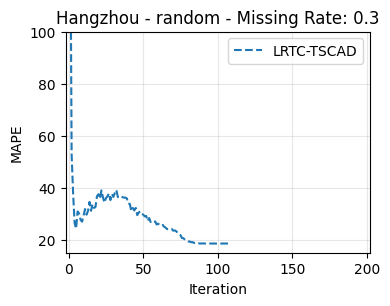

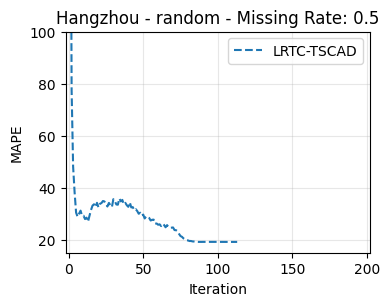

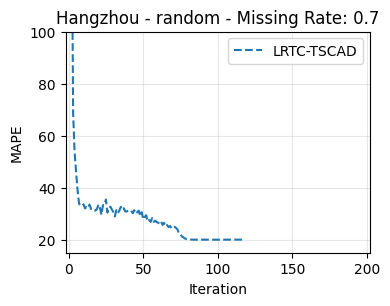

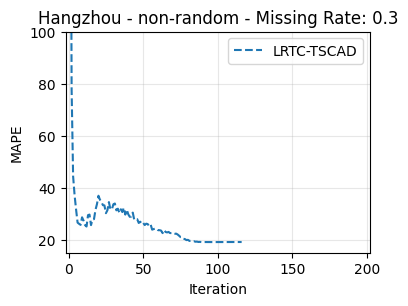

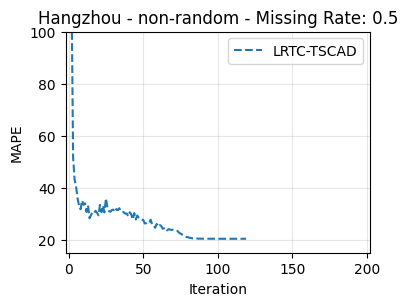

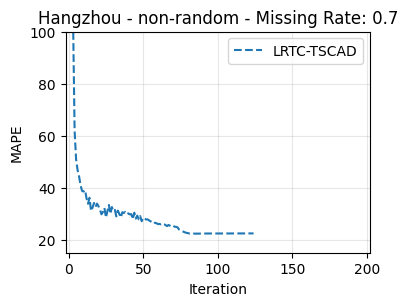

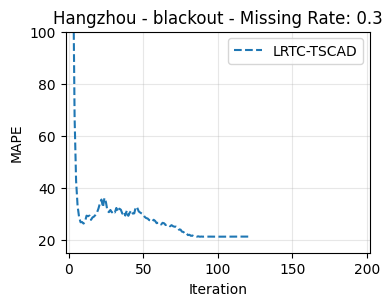

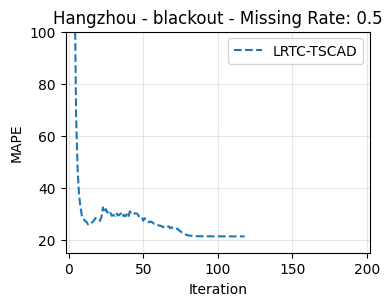

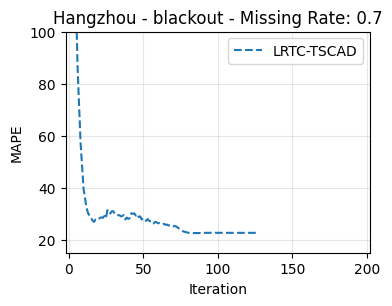

In [5]:
datasets = ["Hangzhou"]

for dataset_name in datasets:
    for kind in ["random", "non-random", "blackout"]:
        logger_dir = f"tscad_{kind}_{dataset_name}"
        logging_save_dir = os.path.join(save_dir, logger_dir)
        # log the iteration results
        if not os.path.exists(logging_save_dir):
            os.makedirs(logging_save_dir)

        initial_rho = 1e-5
        theta0, beta, gamma, lamb = hyper_parameters[dataset_name][kind]
        for missing_rate in missing_rates[kind]:
            logger_info(logger_dir, log_path=os.path.join(logging_save_dir, f"completion_results.log"))
            result_logger = logging.getLogger(logger_dir)
            
            result_logger.info("--------------------------------------------------------------------------------------------------------")
            result_logger.info(f"ms: {missing_rate} \t initial rho: {initial_rho} \t theta0: {theta0} \t beta: {beta} \t gamma: {gamma}.")
            dense_tensor = load_data(dataset_name, dataroot)

            if kind == "blackout":
                if dataset_name in ["Seattle", "PeMS"]:
                    block_window = 12
                elif dataset_name in ["Hangzhou", "Portland"]:
                    block_window = 6
                binary_tensor, binary_blocks = missing_pattern(dense_tensor, missing_rate, kind=kind, block_window=block_window)
            else:
                binary_tensor = missing_pattern(dense_tensor, missing_rate, kind=kind)
            
            sparse_tensor = dense_tensor * binary_tensor
            pos_test = torch.where((dense_tensor != 0) & (sparse_tensor == 0))
            pos_missing = torch.where(sparse_tensor == 0)[0]
            theta = theta0 * np.exp(-beta * len(pos_missing) / (dense_tensor.shape[0] * dense_tensor.shape[1] * dense_tensor.shape[2]))

            M, RMSE, MAPE, used_time = recover_data(
                sparse_tensor, dense_tensor, pos_test, # data and test mask
                initial_rho, theta, gamma, lamb, # algorithm parameters
                logger=result_logger, # logger
                )
            
            fig = plt.figure(figsize=(4, 3))
            plt.grid(alpha=0.3)
            plt.plot(MAPE, "--", label="LRTC-TSCAD")
            plt.xlabel("Iteration")
            plt.ylabel("MAPE")
            plt.legend()
            plt.axis([-2, 202, 15, 100])
            plt.tight_layout()
            plt.title(f"{dataset_name} - {kind} - Missing Rate: {missing_rate}")
            plt.savefig(os.path.join(logging_save_dir, f"missing_rate_{missing_rate}_MAPE.png"), dpi=300, transparent=True)

        logger_close(result_logger)     # close the logger file